## white noise

white noice is type of time series which has no pattern, no trend, no predictiability,no seasonality, think of it like randomness over time
#### definition -- the time series is voice note if
##### 1.mean is constant(usually zero)
##### 2.variance is constant
##### 3.No autocorrelation between values at different time lags(That means today’s value gives you no information about tomorrow’s value.)

## ___________________________________________________________________

#### visual intuition of white noice:

##### 1.Values jump randomly up and down
##### 2.No upward/downward trend
##### 3.No repeating seasonal cycle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
sns.set()

In [2]:
raw_csv_data=pd.read_csv("Index2018.csv")
df_comp=raw_csv_data.copy()
df_comp.date=pd.to_datetime(df_comp.date, dayfirst=True)
df_comp.set_index("date",inplace=True)
df_comp=df_comp.asfreq("b")
df_comp=df_comp.ffill()

In [3]:
df_comp['market_value']=df_comp.spx
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size=int(len(df_comp)*0.8)
df=df_comp.iloc[:size]
df_test=df_comp.iloc[size:]
df.describe()

,market_value
count,5021.000000
mean,1091.651926
std,292.559287
min,438.920000
25%,914.620000
50%,1144.650000
75%,1316.280729
max,1570.252238


### WHITE NOICE

C:\Users\ysriv\AppData\Local\Temp\ipykernel_38108\920430481.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wn']=wn


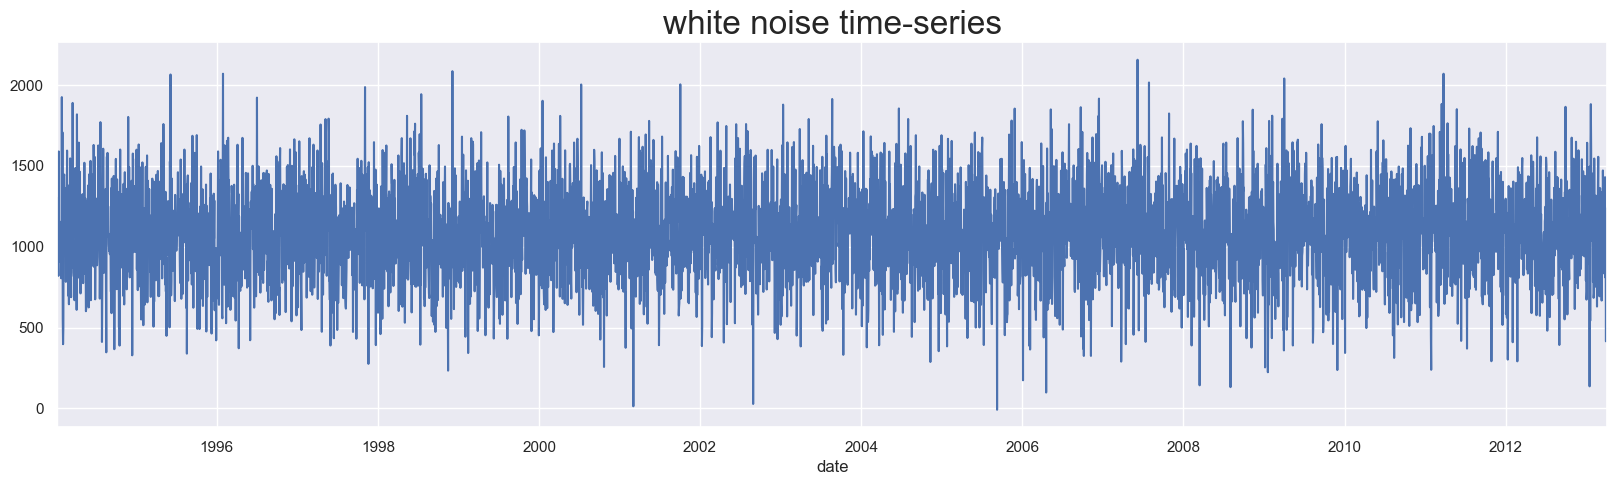

In [4]:
# generate white noice data and plot its values
# plotting the graph of the S&P closing price and compare the two
wn=np.random.normal(loc=df.market_value.mean(),scale=df.market_value.std(),size=len(df))
df['wn']=wn
df.wn.plot(figsize=(20,5))
plt.title("white noise time-series",size=24)
plt.show()

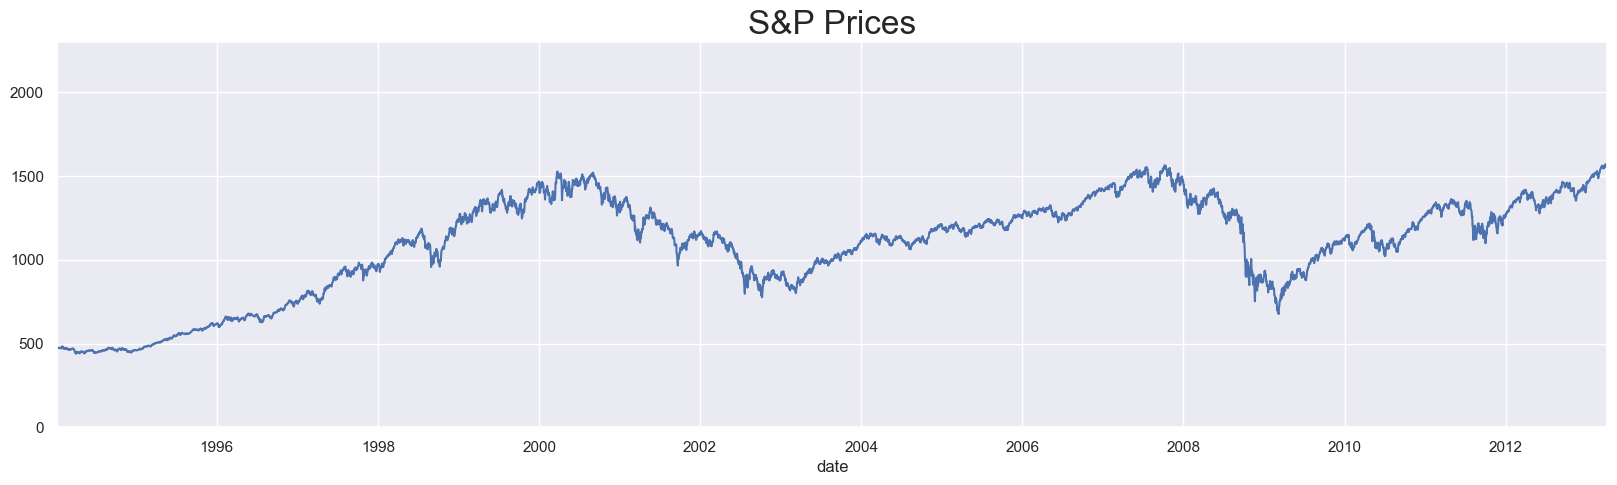

In [5]:
df.market_value.plot(figsize=(20,5))
plt.title("S&P Prices",size=24)
plt.ylim(0,2300)
plt.show()
